In [136]:
# 1. 导入需要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# 2. 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号


In [137]:
# 加载糖尿病数据集
data = load_diabetes()
X = data.data
y = data.target
print(X.shape)
X[0:5]

(442, 10)


array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034],
       [-0.08906294, -0.04464164, -0.01159501, -0.03665608,  0.01219057,
         0.02499059, -0.03603757,  0.03430886,  0.02268774, -0.00936191],
       [ 0.00538306, -0.04464164, -0.03638469,  0.02187239,  0.00393485,
         0.01559614,  0.00814208, -0.00259226, -0.03198764, -0.04664087]])

In [138]:
print(y.shape)
y[0:5]

(442,)


array([151.,  75., 141., 206., 135.])

In [139]:
#数据预处理
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
scaler = StandardScaler() #对数据进行Z-score 标准化
X_train_scaled = scaler.fit_transform(X_train)#训练集标准化
X_test_scaled = scaler.transform(X_test)#测试集标准化
print(X_train_scaled[0:3])
print(X_test_scaled[0:3])

[[ 0.24396182  1.02582922  0.06364526  1.21073305  0.59073628  0.38324757
   0.87925828 -0.83072415  0.07510266  1.49297091]
 [-2.23157066 -0.97482113 -1.56789685 -0.54555389 -1.89176262 -2.02432682
   0.56720281 -1.59866429 -0.8697201  -0.10202047]
 [ 0.54402637  1.02582922 -0.70803006  0.69848269 -0.22702806  0.05070967
  -0.21293587 -0.062784   -0.30602734 -1.02543653]]
[[ 0.3939941   1.02582922  2.15819255  1.50344754 -0.75273371 -0.54785854
  -0.52499134 -0.062784    0.07510266  0.82139559]
 [-0.28115113 -0.97482113  1.25423004  1.13755443  1.02882432  0.64262714
  -0.3689636   0.70515614  1.43269219  0.14982027]
 [ 0.76907478  1.02582922  0.19593245  0.91801856 -0.89876306 -0.4281449
  -0.83704681 -0.062784   -0.37041747  0.14982027]]


In [140]:
# 手动测试不同的k值，找出最优的
k_range = range(1, 31)  # 测试k从1到30
train_errors = []#存放训练集误差
test_errors = []#存放测试集误差
for k in k_range: #不同k值的情况下，误差的大小
    knn=KNeighborsRegressor(n_neighbors=k,weights='uniform')
    knn.fit(X_train_scaled,y_train)#训练模型
    train_pred=knn.predict(X_train_scaled)#预测训练集
    test_pred=knn.predict(X_test_scaled)#预测测试集
    train_rm=np.sqrt(mean_squared_error(y_train, train_pred))#训练集的RMSE
    test_rm=np.sqrt(mean_squared_error(y_test, test_pred))#测试集的RMSE
    #把误差存起来
    train_errors.append(train_rm)
    test_errors.append(test_rm)
# 找最优k值
best_k = k_range[np.argmin(test_errors)]
#最优k值所对应的RMSE
print(best_k)


30


In [141]:
print(test_errors[best_k-1])

56.90030695291397


In [142]:
print(train_errors)
print(test_errors)

[np.float64(0.0), np.float64(38.03385810835173), np.float64(43.671762636135156), np.float64(47.73437962918937), np.float64(48.138959621368656), np.float64(49.56797776048017), np.float64(50.24173396798338), np.float64(50.60713583318029), np.float64(51.30976571274313), np.float64(52.05930726669169), np.float64(52.81205785538041), np.float64(52.85672997679766), np.float64(52.801299096215914), np.float64(52.513801019979994), np.float64(52.60072909466679), np.float64(52.642392979401436), np.float64(53.15499988304518), np.float64(53.19980933111307), np.float64(53.51760311226711), np.float64(53.68642237653825), np.float64(53.674690172836826), np.float64(53.95583597802349), np.float64(54.205814609010666), np.float64(54.25351018475222), np.float64(54.23359635291675), np.float64(54.61632938023125), np.float64(54.76369767743191), np.float64(55.02642460185108), np.float64(55.26477969741478), np.float64(55.337643949642334)]
[np.float64(90.02228188595896), np.float64(74.64776839157817), np.float64(6

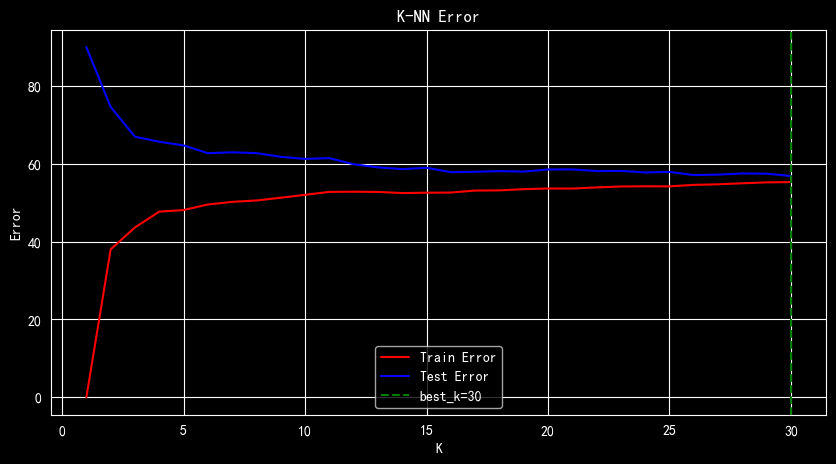

In [143]:
#数据可视化
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_errors, color='red', label='Train Error')
plt.plot(k_range, test_errors, color='blue', label='Test Error')
plt.title('K-NN Error')
plt.xlabel('K')
plt.ylabel('Error')
plt.axvline(x=best_k, color='g', linestyle='--', label=f'best_k={best_k}')
plt.legend()
plt.show()

uniform
30
56.90030695291397

distance
30
57.146203498768756



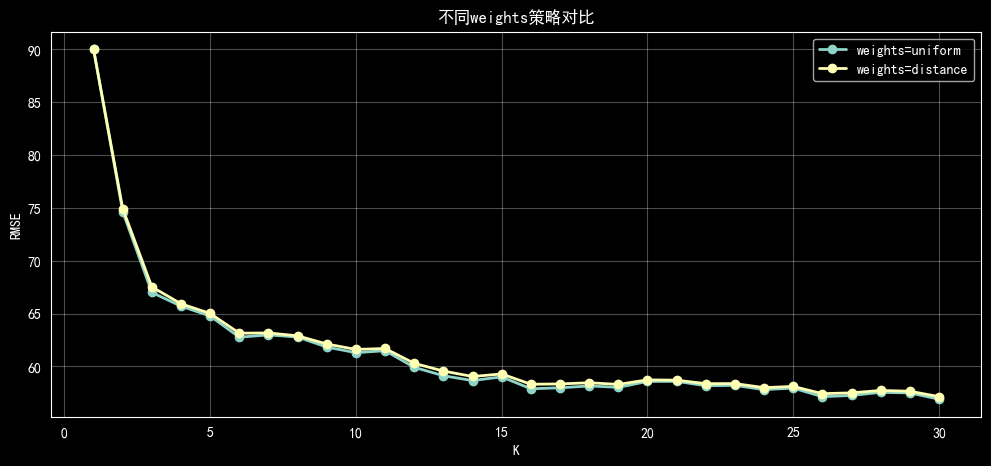

In [146]:
# 对比uniform和distance两种权重方式
weights_options = ['uniform', 'distance']
k_to_test = [i for i in range(1,31)]
plt.figure(figsize=(12, 5))#画布初始化
for weight in weights_options:# 循环两种权重：先uniform，再distance
    test_errors = []#存放误差
    for k in k_to_test:
        # 创建KNN模型，改变weights参数，k为1-30
        knn = KNeighborsRegressor(n_neighbors=k, weights=weight)#创建模型
        knn.fit(X_train_scaled, y_train)#训练模型
        y_pred = knn.predict(X_test_scaled)#预测测试集
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))#计算误差
        test_errors.append(rmse)#误差存入列表
        # 找最优的weight和误差
    best_idx = np.argmin(test_errors)
    print(weight)#输出权重
    print(k_to_test[best_idx])#输出最优k值
    print(test_errors[best_idx],end='\n\n')#输出最小RMSE
    # 画出当前权重的误差曲线
    plt.plot(k_to_test, test_errors, 'o-', label=f'weights={weight}',linewidth=2)
plt.xlabel('K')
plt.ylabel('RMSE')
plt.title('不同weights策略对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [145]:
print(y_pred)

[232.30668704 210.81643761 147.97591541 133.18097333 157.7823742
 224.4996941  100.6471265  191.54447231 144.60688212 204.0338649
 148.13385919 174.89997746 119.21360293 108.75410528 240.70913697
  84.85263386 116.11303199  81.66284042 100.04031645 204.38160512
 144.61849335 135.63268181 146.32871058 117.25426834 170.03419696
 136.96500445 114.70972564  95.87885889 152.13852661 164.12413167
 171.57646768  93.42077741 121.63058726 162.10288929 151.62468494
 183.41026862 160.77116615 168.03802001 109.24747759 198.46537013
 113.28829416 148.09491542 134.7894402  155.88920207 183.09815071
  87.97727818 122.81217558 123.87442294 139.58025211 204.40010622
 142.32708109  79.59405871 139.44817214 156.58129092 216.1724609
 186.44342284 184.62347072 104.31460529 141.40023131 175.12069724
 185.14615782 144.97051415 160.1606306  124.42210686 224.92142749
 133.3639036   97.81760798 209.48621732 185.78809843  89.24036339
  84.44346505 150.34324072 103.90462416 106.40117626 110.81395823
 170.65763715